Q6] Principle Component Analysis

Unsupervised learning algorithms like PCA (Principal Component Analysis) are useful when we don’t have labeled data. PCA helps us find hidden patterns and structure in the data by reducing its dimensions, meaning it keeps the important information while removing less useful parts. This makes the data easier to understand, visualize, and work with. By simplifying the data, PCA can also speed up other machine learning algorithms and reduce noise.

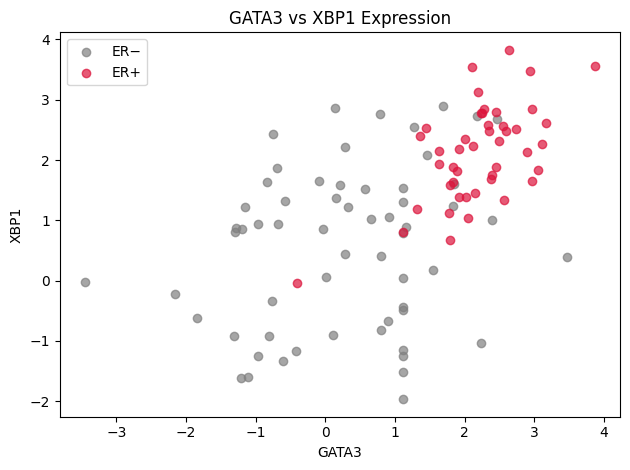

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/filtered.tsv", sep="\t")
cls = pd.read_csv("data/class.tsv", sep="\t", header=None)
meta = pd.read_csv("data/columns.tsv", sep="\t", comment="#")    

# Get gene column IDs
g1 = " " + str(meta.loc[meta['GeneSymbol'] == 'GATA3', 'ID'].values[0])
g2 = " " + str(meta.loc[meta['GeneSymbol'] == 'XBP1', 'ID'].values[0])

# Extract expression values
x = df[g1].values
y = df[g2].values
z = cls[0].values

# Masks
m0 = (z == 0)
m1 = (z == 1)

# Scatter plot
plt.scatter(x[m0], y[m0], color='gray', alpha=0.7, label='ER−')
plt.scatter(x[m1], y[m1], color='crimson', alpha=0.7, label='ER+')
plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("GATA3 vs XBP1 Expression")
plt.legend()
plt.tight_layout()
plt.show()



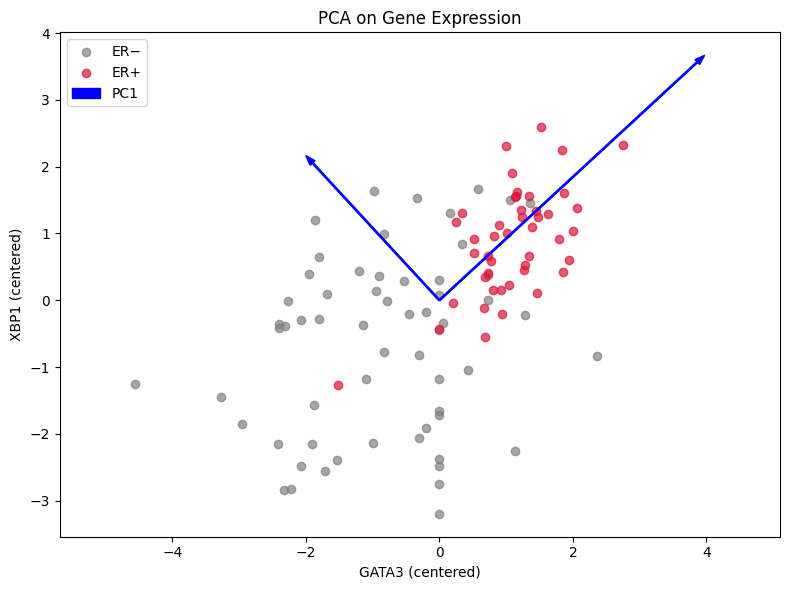

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manual PCA
data = np.vstack((x, y)).T
mean = np.mean(data, axis=0)
centered = data - mean

cov = np.cov(centered.T)
vals, vecs = np.linalg.eig(cov)

# Sort eigenvectors
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

# Plot with PCA vectors
plt.figure(figsize=(8, 6))
plt.scatter(centered[m0, 0], centered[m0, 1], color='gray', alpha=0.7, label='ER−')
plt.scatter(centered[m1, 0], centered[m1, 1], color='crimson', alpha=0.7, label='ER+')

# Draw PCA arrows
for i in range(2):
    plt.arrow(0, 0,
              vecs[0, i] * np.sqrt(vals[i]) * 3,
              vecs[1, i] * np.sqrt(vals[i]) * 3,
              color='blue', width=0.02, head_width=0.1,
              label=f'PC{i+1}' if i == 0 else None)

plt.xlabel("GATA3 (centered)")
plt.ylabel("XBP1 (centered)")
plt.title("PCA on Gene Expression")
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


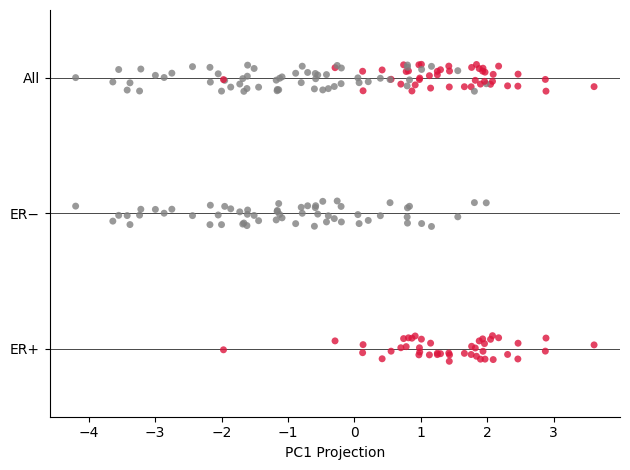

In [13]:
# PC1 projection
pc1 = vecs[:, 0]
proj = centered @ pc1

# Prepare DataFrame for strip plot
df_all = pd.DataFrame({
    "PC1": proj,
    "Group": "All",
    "Color": np.where(z == 0, "gray", "crimson")
})

df_er0 = pd.DataFrame({"PC1": proj[z == 0], "Group": "ER−", "Color": "gray"})
df_er1 = pd.DataFrame({"PC1": proj[z == 1], "Group": "ER+", "Color": "crimson"})

# Combine all
final_df = pd.concat([df_all, df_er0, df_er1], ignore_index=True)

# Strip plot
ax = sns.stripplot(data=final_df, x="PC1", y="Group", hue="Color",
                   palette={"gray": "gray", "crimson": "crimson"},
                   dodge=False, jitter=True, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5)
plt.xlabel("PC1 Projection")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()